In [1]:
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pyplot as plt 

#### 1. Understanding Basic Structure of the Data

In [2]:
df = pd.read_excel("Payment1.xlsx")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df[
  (df['isFraud']==0) &
  (df['amount'] > df['oldbalanceOrg']) & (df['newbalanceOrig']==0)
]['type'].value_counts()

type
CASH_OUT    28498
PAYMENT     17262
TRANSFER     8487
DEBIT         212
Name: count, dtype: int64

In [3]:
print("No of Rows :",df.shape[0])
print("No of Columns :",df.shape[1])

No of Rows : 105599
No of Columns : 11


In [4]:
df.dtypes # Datatypes of ("type","nameOrig", "nameDest") are objects

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [13]:
df.isna().sum()  # No missing values in any column

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [49]:
df.describe()  # Statistic summary

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,diffOrg,diffDest
count,105599.000000,1.055990e+05,1.055990e+05,1.055990e+05,1.055990e+05,1.055990e+05,105599.000000,105599.0,1.055990e+05,1.055990e+05
mean,8.579191,1.751804e+05,9.098669e+05,9.260737e+05,8.842665e+05,1.186197e+06,0.001136,0.0,-1.620680e+04,3.019309e+05
std,1.808021,3.466798e+05,2.825412e+06,2.863106e+06,2.394115e+06,2.787382e+06,0.033691,0.0,1.362024e+05,9.817816e+05
min,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,-1.289408e+06,-1.306083e+07
25%,8.000000,1.013800e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00
50%,9.000000,5.471065e+04,2.024500e+04,0.000000e+00,2.218700e+04,5.723859e+04,0.000000,0.0,0.000000e+00,0.000000e+00
75%,10.000000,2.135625e+05,1.990070e+05,2.237769e+05,6.024036e+05,1.079004e+06,0.000000,0.0,1.016550e+04,2.612532e+05
max,10.000000,1.000000e+07,3.893942e+07,3.894623e+07,3.400874e+07,3.894623e+07,1.000000,0.0,1.000000e+07,3.889205e+07


### 2. Univariate Analysis

#### a) Categorical columns

##### countplot for most frequent type of payment

<Axes: xlabel='type', ylabel='count'>

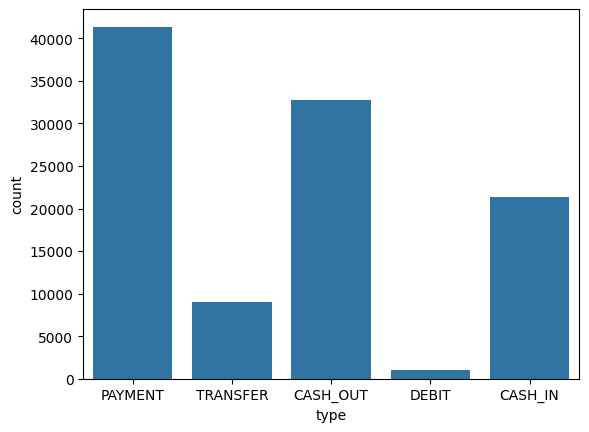

In [17]:
sns.countplot(df,x="type") # Payment type is the most frequent type of transaction

##### countplot for fraud vs nonfraud distribution

<Axes: xlabel='isFraud', ylabel='count'>

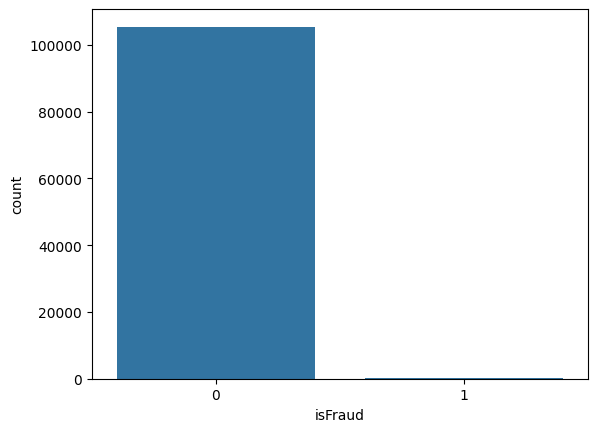

In [19]:
sns.countplot(df,x="isFraud")  # (typically highly imbalanced)

#### b) Numerical columns

##### Distribution of 'amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest

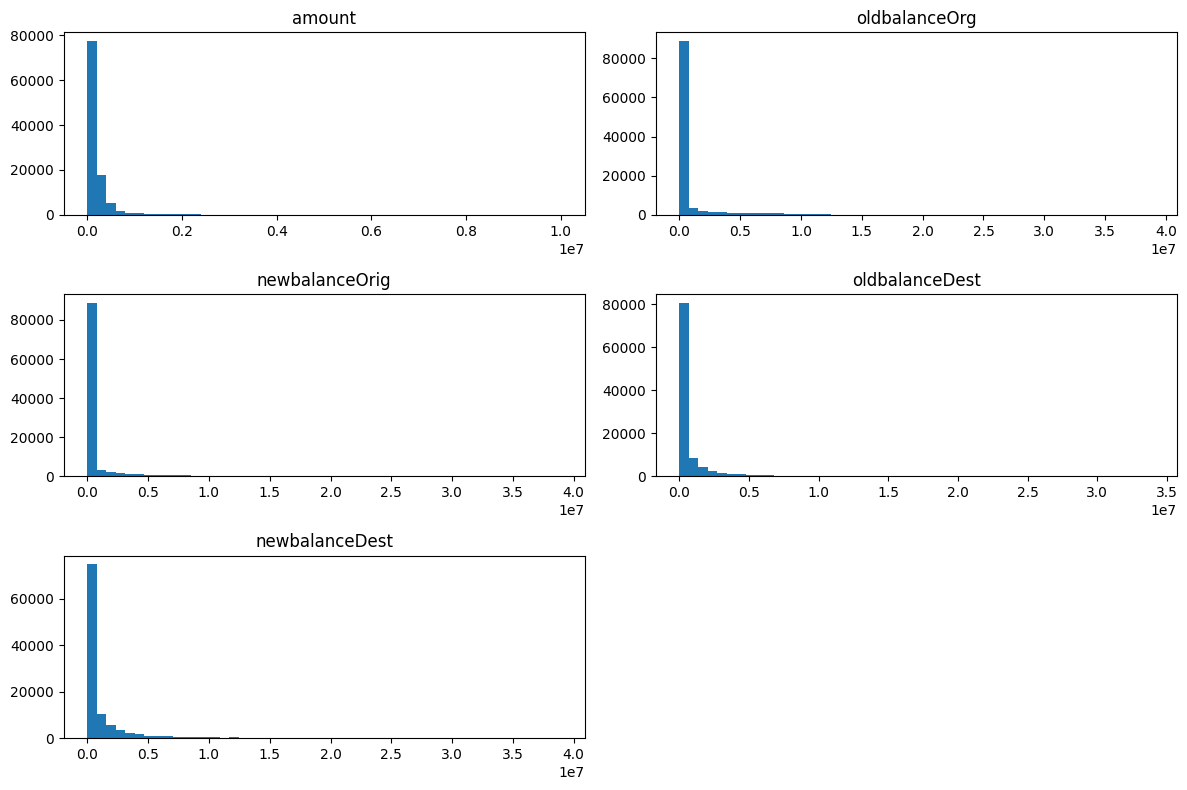

In [38]:
df[['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']].hist(
    bins=50, 
    figsize=(12,8),
    grid=False)
plt.tight_layout()   ## data is highly Skewed
plt.show()

##### Boxplot for numerical columns

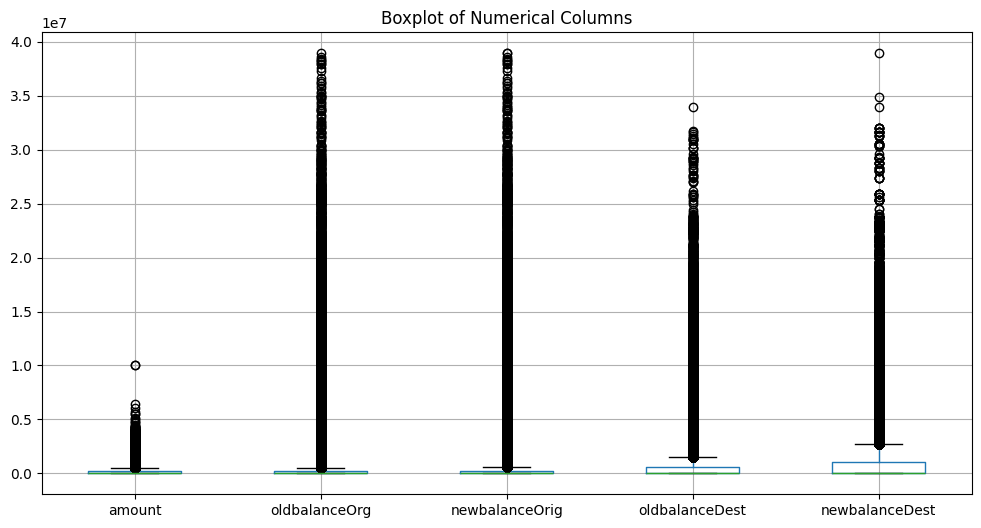

In [5]:
df[['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']].boxplot(figsize=(12,6))
plt.title("Boxplot of Numerical Columns")   # Detecting outliers using boxplots
plt.show()

In [ ]:
# Outliers are detected in the 'Amount','oldbalancedest','newbalanceDest' columns

##### Log-transformed plots for outliers columns

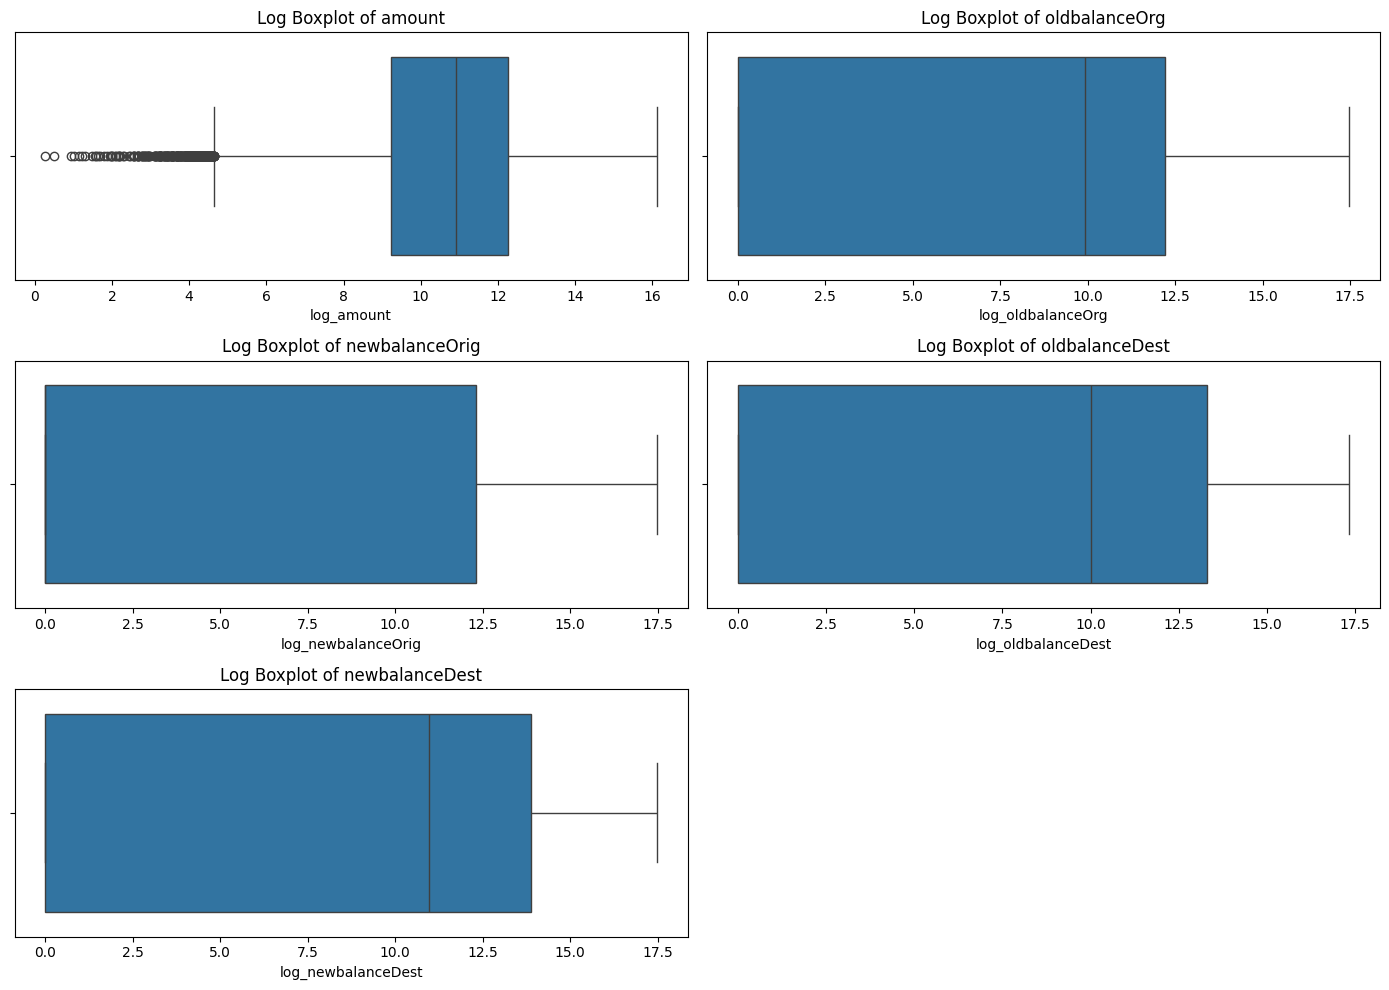

In [41]:
num_cols = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']
for col in num_cols:
    df['log_' + col] = np.log1p(df[col])  
plt.figure(figsize=(14,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=df['log_' + col])
    plt.title(f"Log Boxplot of {col}")

plt.tight_layout()
plt.show()

### 3. Bivariate Analysis

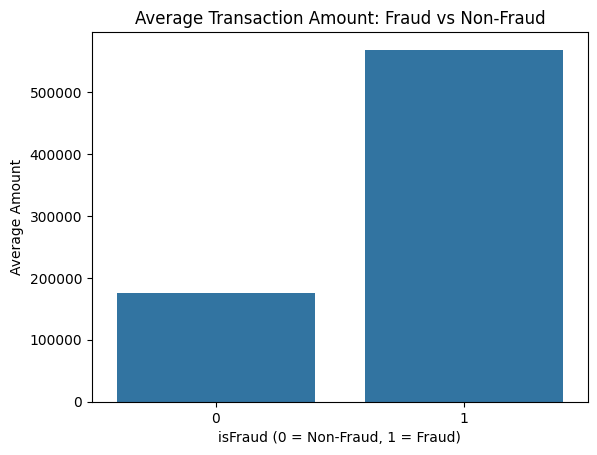

In [51]:
avg_amount = df.groupby("isFraud")["amount"].mean().reset_index()

sns.barplot(data=avg_amount, x="isFraud", y="amount")   #Comparing average amount for fraudulent vs non-fraudulent transactions
plt.title("Average Transaction Amount: Fraud vs Non-Fraud")   
plt.xlabel("isFraud (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Average Amount")
plt.show()

##### Compare type distribution for fraudulent transactions.

In [58]:
fraud_counts = df[df['isFraud'] == 1]['type'].value_counts()
print(fraud_counts)

type
CASH_OUT    61
TRANSFER    59
Name: count, dtype: int64


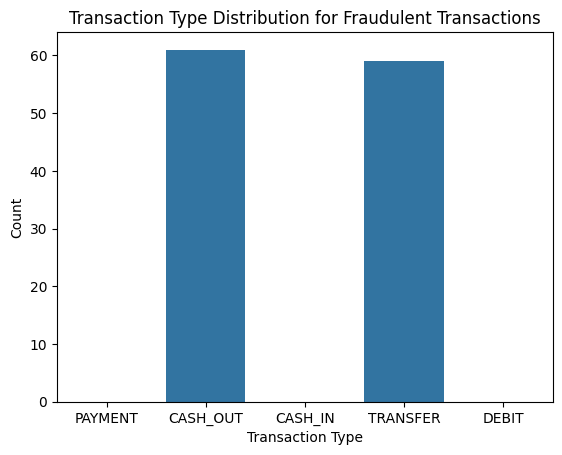

In [58]:
sns.countplot(data=df[df['isFraud'] == 1], x='type', order=df['type'].value_counts().index)
plt.title("Transaction Type Distribution for Fraudulent Transactions")
plt.xlabel("Transaction Type")   # in the Countplot format
plt.ylabel("Count")
plt.show()  #Fraud usually happens mostly in TRANSFER and CASH_OUT.

#### Ploting correlation between:

#### a) oldbalanceOrg → newbalanceOrg

In [59]:
correlation_value = df['oldbalanceOrg'].corr(df['newbalanceOrig'])
correlation_value

np.float64(0.9989411977844026)

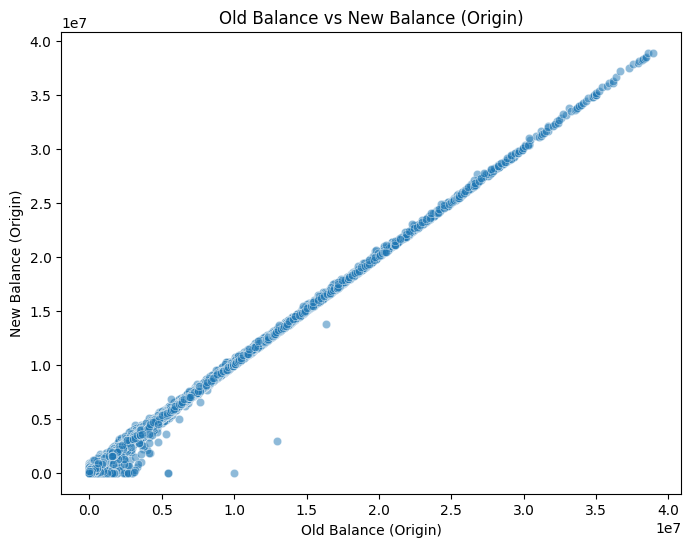

Correlation coefficient between oldbalanceOrg and newbalanceOrg: 1.00


In [60]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='oldbalanceOrg', y='newbalanceOrig', data=df, alpha=0.5)
plt.title('Old Balance vs New Balance (Origin)')
plt.xlabel('Old Balance (Origin)')
plt.ylabel('New Balance (Origin)')
plt.show()
corr = df['oldbalanceOrg'].corr(df['newbalanceOrig'])
print(f'Correlation coefficient between oldbalanceOrg and newbalanceOrg: {corr:.2f}')

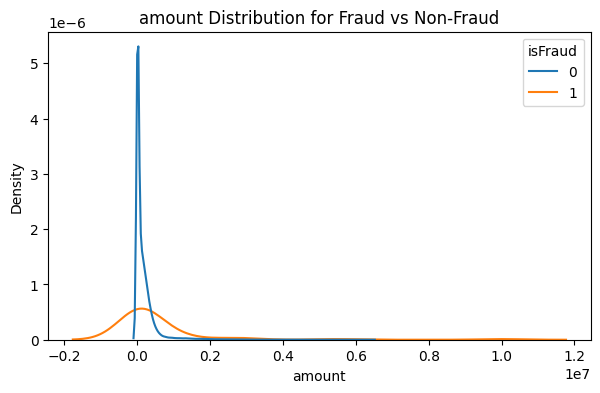

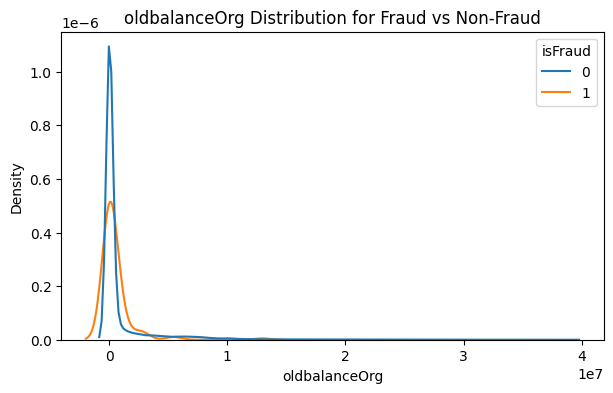

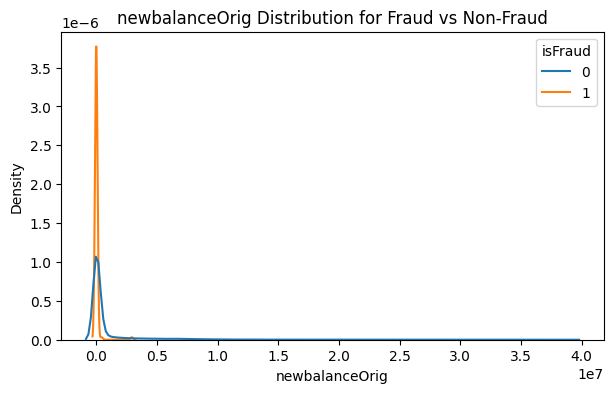

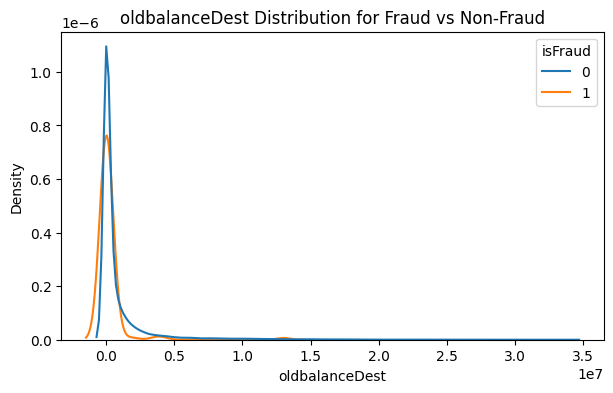

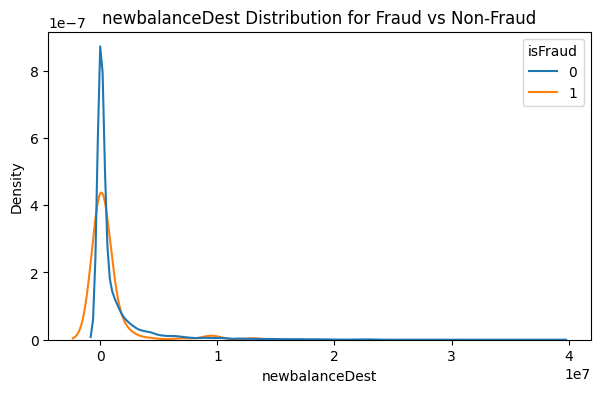

In [46]:
num_cols = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=df, x=col, hue="isFraud", common_norm=False)
    plt.title(f"{col} Distribution for Fraud vs Non-Fraud")
    plt.show()

#### co-relations between newbalanceOrig vs oldbalanceOrg 

In [11]:
df[['oldbalanceOrg', 'newbalanceOrig']].corr()  # showing strongly positive relation

,oldbalanceOrg,newbalanceOrig
oldbalanceOrg,1.000000,0.998941
newbalanceOrig,0.998941,1.000000


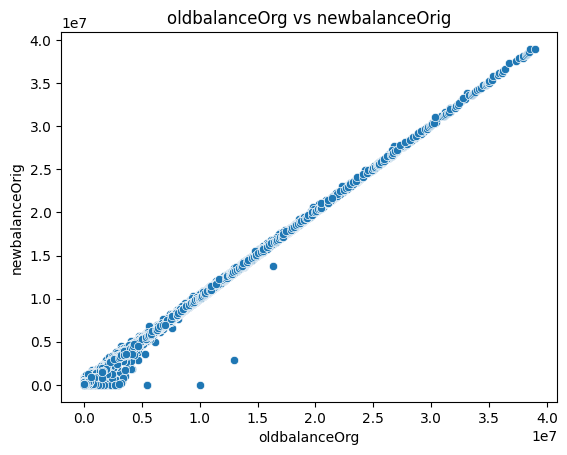

In [59]:
sns.scatterplot(data=df, x='oldbalanceOrg', y='newbalanceOrig') 
plt.title("oldbalanceOrg vs newbalanceOrig")
plt.show()

#### ploting co-relation between oldbalanceDest → newbalanceDest

In [18]:
df[['oldbalanceDest', 'newbalanceDest']].corr() 

,oldbalanceDest,newbalanceDest
oldbalanceDest,1.000000,0.939368
newbalanceDest,0.939368,1.000000


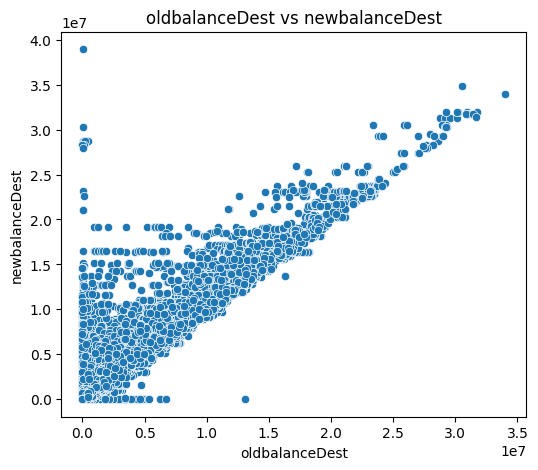

In [24]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='oldbalanceDest', y='newbalanceDest') 
plt.title("oldbalanceDest vs newbalanceDest") #Many fraud transactions have oldbalanceDest = 0 and newbalanceDest = 0
plt.show()

### Relationship Plots

#### 1)amount vs oldbalanceOrg

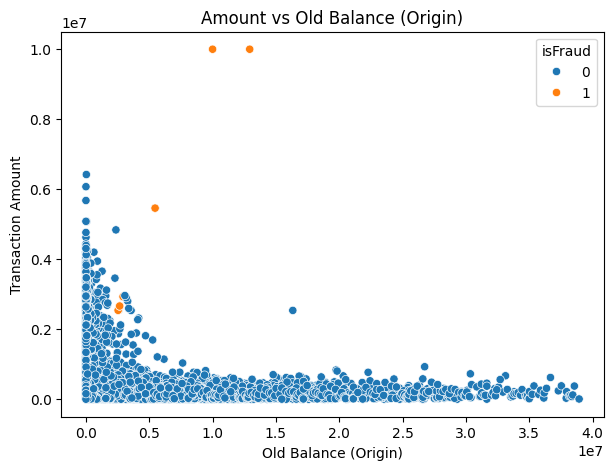

In [23]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='oldbalanceOrg', y='amount', hue='isFraud')
plt.title("Amount vs Old Balance (Origin)")
plt.xlabel("Old Balance (Origin)")
plt.ylabel("Transaction Amount")   #Non-fraud: points form a diagonal-like trend
plt.show()                          #Fraud: often appears with small oldbalanceOrg but high amount

#### 2) amount vs newbalanceDest

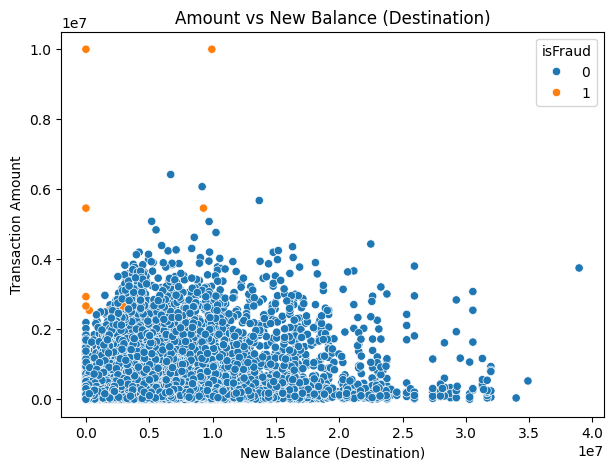

In [26]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='newbalanceDest', y='amount', hue='isFraud')
plt.title("Amount vs New Balance (Destination)")
plt.xlabel("New Balance (Destination)")     
plt.ylabel("Transaction Amount")
plt.show()   #Non-fraud: newbalanceDest increases consistently with amount
             #Fraud: mismatched points (balance doesn't update correctly)

#### 3)Fraud count vs step (time)

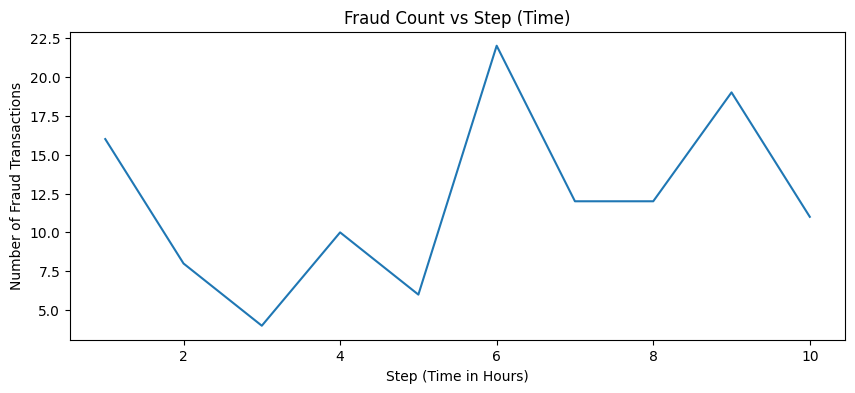

In [27]:
fraud_per_step = df.groupby('step')['isFraud'].sum().reset_index()
plt.figure(figsize=(10,4))
sns.lineplot(data=fraud_per_step, x='step', y='isFraud')
plt.title("Fraud Count vs Step (Time)")
plt.xlabel("Step (Time in Hours)")
plt.ylabel("Number of Fraud Transactions")
plt.show()   #Fraud tends to spike at 6th step

## FEATURE SELECTION

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report , accuracy_score 
from sklearn.preprocessing import MinMaxScaler , StandardScaler

In [12]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [4]:
df=pd.get_dummies(df,columns=['type'],dtype=int)
df.head(3)

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0,0,0,1,0
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0,0,0,1,0
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0,0,0,0,1


In [ ]:
""" Here we have drop the two columns named ['nameOrig','nameDest','isFlaggedFraud'] because it have so much data and encoding 
is not possible on it. 
"""

In [5]:
x = df.drop(['isFraud','nameOrig','nameDest','isFlaggedFraud'], axis=1)
y = df['isFraud']

### Feature Engineering

#### Scaling

In [6]:
x = df.drop(['isFraud','nameOrig','nameDest','isFlaggedFraud'], axis=1)
y = df['isFraud']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [8]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(
    sampling_strategy=0.4,   # fraud becomes 10% of non-fraud
    random_state=42,
    k_neighbors=5
)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train_scaled,y_train
)

In [9]:
log_model = LogisticRegression()

log_model.fit(x_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
print("**************Training data evaluation****************")
y_pred_train = log_model.predict(x_train_smote)
cnf_mat=confusion_matrix(y_train_smote,y_pred_train)
print("confusion matrix is \n",cnf_mat)
print('*'*25)
clf_report= classification_report(y_train_smote,y_pred_train)
print("classification report is \n",clf_report)
acc=accuracy_score(y_train_smote,y_pred_train)
print("Accuracty score  is \n",acc)
print("**************Testing data evaluation****************")
y_pred_test = log_model.predict(x_test)
cnf_mat=confusion_matrix(y_test,y_pred_test)
print("confusion matrix is \n",cnf_mat)
print('*'*25)
clf_report= classification_report(y_test,y_pred_test)
print("classification report is \n",clf_report)                                 
acc=accuracy_score(y_test,y_pred_test)
print("Accuracty score  is \n",acc)            

**************Training data evaluation****************
confusion matrix is 
 [[82026  2357]
 [ 4226 29527]]
*************************
classification report is 
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     84383
           1       0.93      0.87      0.90     33753

    accuracy                           0.94    118136
   macro avg       0.94      0.92      0.93    118136
weighted avg       0.94      0.94      0.94    118136

Accuracty score  is 
 0.9442760885758786
**************Testing data evaluation****************
confusion matrix is 
 [[17696  3400]
 [    1    23]]
*************************
classification report is 
               precision    recall  f1-score   support

           0       1.00      0.84      0.91     21096
           1       0.01      0.96      0.01        24

    accuracy                           0.84     21120
   macro avg       0.50      0.90      0.46     21120
weighted avg       1.00      0.84      

In [11]:
import pickle
import json

In [12]:
with open("lg_model.pkl","wb") as file:
    pickle.dump(log_model,file)

In [13]:
df.columns

Index(['step', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT',
       'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')

In [14]:
label_enc_data = {
                 "columns_name" : list(x_train.columns)}

with open("label_enc_data.json","w") as file:
    json.dump(label_enc_data,file)

In [40]:
x_train.head(1
            )

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
68189,9,62317.12,0.0,0.0,82453.36,0.0,0,1,0,0,0


In [19]:
x_train.columns

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT',
       'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')

In [20]:
step = 5
amount = 15000
oldbalanceOrg = 50000
newbalanceOrig = 00.0
oldbalanceDest = 500
newbalanceDest = 155000
type =  "PAYMENT"
type=f"type_{type}"
type


'type_PAYMENT'

In [23]:
columns_names=x_train.columns

In [24]:
test_array = np.zeros((1,len(columns_names)))
test_array[0,0] =step
test_array[0,1] = amount
test_array[0,2] = oldbalanceOrg
test_array[0,3] = newbalanceOrig
test_array[0,4] = oldbalanceDest
test_array[0,5] = newbalanceDest

index_type = np.where(columns_names == type)
test_array[0,index_type] = 1

test_array

array([[5.00e+00, 1.50e+04, 5.00e+04, 0.00e+00, 5.00e+02, 1.55e+05,
        0.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00]])

In [25]:
prediction_user_data = log_model.predict(test_array)
if prediction_user_data == 0:
    print('The transaction is not Fraud')
if prediction_user_data == 1:
    print('The transaction is Fraud')
# print("the transaction is ",prediction_user_data[0])

The transaction is Fraud
